Aims:  
- Using the five folds cross-validation to validate the model performance in the independent slide
    
Tasks:  
    1. Cellular Density distribution: We don't want to predict the density, because we care about the niche recall, which is more useful in evaluating the model performance. So we only show the control and disease density performance in thie notebook.  
    2. Cellular Composition: We want to figure out the accuracy of our model in capturin the cell types of the neighbors. We need to compare the ground-truth cell type distribution with the predicted cell type distribution.  
    3. Cellular colocalization: use 5 folds cross niche validation to test the performance. The test cells should not be leaked in the training cellular pairs, including positive and negative pairs, so all the edges link to the test cells are excluded.

# Cellular Density distribution

In [2]:
from datasets import load_from_disk
import sys
sys.path.append("/scratch/project_465001027/Spatialformer/utils")
from utils import *
import seaborn as sns

Getting the distribution of the normal and disease density distribution

In [12]:
Healthy_samples = ["THD0008","THD0011","VUHD069","VUHD095","VUHD113","VUHD116A","VUHD116B"]
Disease_samples = ["TILD117LF","TILD117MF","TILD175","VUILD78LF","VUILD78MF","VUILD91LF",
                   "TILD117LF","TILD117MF","TILD175","VUILD78LF","VUILD78MF","VUILD91LF",
                   "VUILD91MF","VUILD48MF","VUILD104LF","VUILD105MF","VUILD96LF","VUILD96MF",
                   "VUILD102LF","VUILD102MF","VUILD107MF"]

In [5]:
combined_dataset = load_from_disk("/scratch/project_465001027/Spatialformer/cache/xenium_pandavid_dataset4")  
index_path = "/scratch/project_465001027/Spatialformer/data/sample_cell_index.pkl"
sample_cell_index = get_index(combined_dataset, save_file = index_path)
# sample_name = "THD0008" #Healthy
combined_dataset_all = concatenate_datasets([combined_dataset["train"], combined_dataset["test"], combined_dataset["validation"]])
# sample_dataset = combined_dataset_all.select(list(sample_cell_index[sample_name].values()))


Loading dataset from disk:   0%|          | 0/364 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/114 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/91 [00:00<?, ?it/s]

Calulating all the distribution

In [39]:
def get_density_count(sample_name):
    sample_dataset = combined_dataset_all.select(list(sample_cell_index[sample_name].values()))
    # def get_density(sample_dataset, sparse_adj):
    sparse_adj, cell_ids = get_adj(sample_dataset, radius = 30, plot = False, sym = True)
    sparse_adj = sparse_adj.tocsr() 
    density = np.array(sparse_adj.sum(axis=1))
    # non_zero_values = dense_array[dense_array != 0]

    # Calculate density (if you want the density of non-zero values)
    density, counts = np.unique(density, return_counts=True)
    return density, counts
h_density = []
h_count = []
d_density = []
d_count = []

for sample in Healthy_samples:
    print(f"Healthy {sample} running")
    density, counts = get_density_count(sample)
#     print(density)
    h_density.append(density)
    h_count.append(counts)

for sample in Disease_samples:
    print(f"Disease {sample} running")
    density, counts = get_density_count(sample)
#     print(density)
    d_density.append(density)
    d_count.append(counts)

Healthy THD0008 running
Healthy THD0011 running
Healthy VUHD069 running
Healthy VUHD095 running
Healthy VUHD113 running
Healthy VUHD116A running
Healthy VUHD116B running
Disease TILD117LF running
Disease TILD117MF running
Disease TILD175 running
Disease VUILD78LF running
Disease VUILD78MF running
Disease VUILD91LF running
Disease TILD117LF running
Disease TILD117MF running
Disease TILD175 running
Disease VUILD78LF running
Disease VUILD78MF running
Disease VUILD91LF running
Disease VUILD91MF running
Disease VUILD48MF running
Disease VUILD104LF running
Disease VUILD105MF running
Disease VUILD96LF running
Disease VUILD96MF running
Disease VUILD102LF running
Disease VUILD102MF running
Disease VUILD107MF running


In [79]:
#integrate all the sample results
h_density_np = np.hstack(h_density)
h_count_np = np.hstack(h_count)/np.sum(np.hstack(h_count))


d_density_np = np.hstack(d_density)
d_count_np = np.hstack(d_count)/np.sum(np.hstack(d_count))


Plot the healthy density distribution

In [86]:
disease_df['Density'] += 0.05 
disease_df

,Density,Counts
0,0.05,0.001443
1,1.05,0.003637
2,2.05,0.007575
3,3.05,0.013776
4,4.05,0.021307
5,5.05,0.030051
6,6.05,0.037540
7,7.05,0.045030
8,8.05,0.051033
9,9.05,0.055324


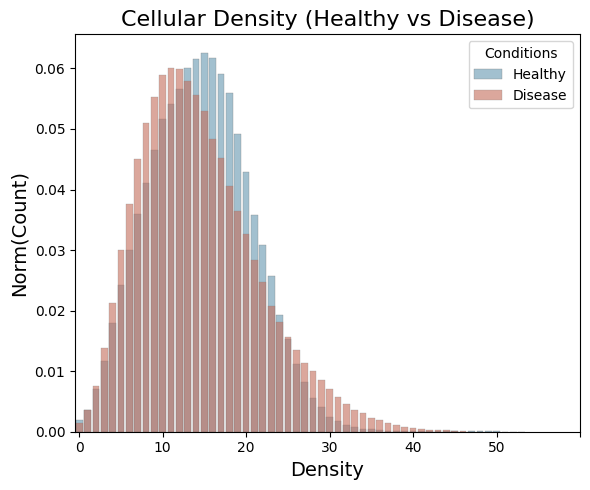

In [117]:
# Create a DataFrame for easier plotting
healthy_df = pd.DataFrame({'Density': h_density_np, 'Counts': h_count_np})
healthy_df = healthy_df.groupby('Density', as_index=False).sum()

# Create a DataFrame for easier plotting
disease_df = pd.DataFrame({'Density': d_density_np, 'Counts': d_count_np})
disease_df = disease_df.groupby('Density', as_index=False).sum()

# disease_df['Density'] += 0.01 
# Create the bar plot
plt.figure(figsize=(6, 5))
# Create a bar plot for healthy data
sns.barplot(data=healthy_df, x='Density', y='Counts', color='#81B5CD', width=0.8, alpha=0.8, label='Healthy')
# Create a bar plot for disease data with an offset
sns.barplot(data=disease_df, x='Density', y='Counts', color='#D5614A', width=0.8, alpha=0.6, label='Disease')

# Add a frame around each bar
for bar in plt.gca().patches:
    bar.set_edgecolor('grey')  # Set the edge color for the bars
    bar.set_linewidth(0.3)       

plt.title('Cellular Density (Healthy vs Disease)', fontsize=16)
plt.xlabel('Density', fontsize=14)
plt.ylabel('Norm(Count)', fontsize=14)

# Set x-axis ticks
plt.xticks(ticks=range(0, int(healthy_df['Density'].max()) + 10, 10), rotation=0)


# Show the legend
plt.legend(title='Conditions')
plt.tight_layout()
plt.show()

# Cellular composition

In [49]:
import numpy as np

def kl_divergence(p, q):
    """Compute the KL divergence D(p || q)."""
    return np.sum(np.where(p != 0, p * np.log(p / q), 0))

def jsd(p, q):
    """Compute the Jensen-Shannon Divergence between two probability distributions."""
    # Normalize p and q to ensure they are valid distributions
    p = p / np.sum(p)
    q = q / np.sum(q)
    
    # Compute M
    m = 0.5 * (p + q)
    
    # Compute JSD
    return 0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m)

def count_JSD(P_counts, Q_counts):
    
    # Compute probability distributions
    P = P_counts / np.sum(P_counts)
    Q = Q_counts / np.sum(Q_counts)
    # Compute JSD
    jsd_score = jsd(P, Q)
    print("Jensen-Shannon Divergence (JSD) score:", jsd_score)
    return jsd_score

In [48]:
def get_cell_comp(sparse_adj, sample_dataset, prob):
    cell_composition = {}
    sparse_adj = sparse_adj.tocsr() 
    Anns = sample_dataset["Annotations"]
    unique_types = sorted(Anns)  # Sort for consistent indexing
    nb_dict = {ct: 0 for ct in unique_types}  
    
    for cell_id in tqdm(range(sparse_adj.shape[0])):

        indices_of_one = sparse_adj[[cell_id], :].nonzero()[1]  # Get the column indices of the non-zero entries
        
        # Convert indices to a list of annotations
        if indices_of_one.size > 0:  # Check if any connected cells were found
            for indice in indices_of_one:
                nb_dict[Anns[indice]] += 1
            if prob:
                ct_num = np.sum(list(nb_dict.values()))
                for ct in nb_dict.keys():
                    nb_dict[ct] = nb_dict[ct]/ct_num
            
            cell_composition[cell_id] = nb_dict
            nb_dict = {ct: 0 for ct in unique_types}  


    return cell_composition

In [52]:
sample_name = "THD0008"
sample_dataset = combined_dataset_all.select(list(sample_cell_index[sample_name].values()))

In [53]:
sparse_adj, cell_ids = get_adj(sample_dataset, radius = 30, plot = False, sym = False)

Get the cellular composition - ground truth

In [54]:
cell_composition = get_cell_comp(sparse_adj, sample_dataset, prob=False)

100%|██████████| 57012/57012 [01:39<00:00, 573.70it/s]
